# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 06: Árvores de Decisão e k-Means**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_06_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
url = "https://gist.githubusercontent.com/marcelovca90/de69333ef1e36f6ce4671e387f820f34/raw/29d61f2789c51a84144192a8127c5b041fa8bca2/wifi_localization.txt"

column_names = [ "AP1", "AP2", "AP3", "AP4", "AP5", "AP6", "AP7", "Room" ]

df = pd.read_csv(url, sep="\t", header=None, names=column_names)

X = df.drop(columns=["Room"]).values
y = df["Room"].values

feature_names = df.columns[:-1].tolist()

df.head()

,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


### <font color='#2D9CDB'>Q1) O Wireless Indoor Localization [[1]](https://archive.ics.uci.edu/dataset/422/wireless+indoor+localization)[[2]](https://archive-beta.ics.uci.edu/dataset/422/wireless+indoor+localization) é um conjunto de dados amplamente utilizado em pesquisas sobre posicionamento indoor e redes sem fio. Pesquise brevemente sobre esse dataset e descreva, em um único parágrafo, qual é o problema que ele busca resolver, quais informações são registradas em cada amostra, o significado dos valores RSSI (Received Signal Strength Indicator) e por que essa base de dados pode ser utilizada tanto em problemas de classificação quanto de clusterização.</font>

O dataset busca identificar em qual sala uma pessoa/dispositivo está a partir da intensidade dos sinais Wi-Fi captados por um smartphone. A base possui 2000 amostras, em que cada registro contém os valores de intensidade de sinal de sete pontos de acesso Wi-Fi (AP1 a AP7) e uma variável-alvo indicando uma entre quatro salas possíveis. Esses valores são medidas de RSSI, que representam a potência do sinal recebido. Valores menos negativos indicam sinal mais forte, enquanto valores mais negativos indicam sinal mais fraco. A base pode ser usada em classificação porque existe um rótulo conhecido, a sala, que o modelo tenta prever, também pode ser usada em clusterização porque é possível ignorar esse rótulo e tentar agrupar automaticamente as amostras com padrões semelhantes de RSSI, verificando se os grupos formados correspondem às salas reais.

### <font color='#2D9CDB'>Q2) Utilizando o dataset Wireless Indoor Localization já carregado, informe a quantidade total de amostras, o número de atributos, o número de classes e os identificadores das salas presentes na base de dados. Em seguida, apresente uma tabela contendo as cinco primeiras amostras do conjunto de dados. Com base nos resultados obtidos, descreva brevemente a estrutura do dataset e o significado dos atributos e da variável alvo.</font>

In [4]:
total_amostras = df.shape[0]
numero_atributos = X.shape[1]
numero_classes = df["Room"].nunique()
salas = sorted(df["Room"].unique())

print(f"Quantidade total de amostras: {total_amostras}")
print(f"Número de atributos: {numero_atributos}")
print(f"Número de classes: {numero_classes}")
print(f"Identificadores das salas: {salas}")

# Cinco primeiras amostras
df.head()

Quantidade total de amostras: 2000
Número de atributos: 7
Número de classes: 4
Identificadores das salas: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


O dataset possui 2000 amostras, 7 atributos e 4 classes, representadas pelas salas 1, 2, 3 e 4. As colunas AP1 a AP7 indicam os valores de RSSI dos sinais Wi-Fi recebidos de sete pontos de acesso. A coluna Room é a variável alvo e informa a sala onde a amostra foi coletada. Assim, os atributos representam o padrão de sinal Wi-Fi e o alvo representa a localização indoor correspondente.

### <font color='#2D9CDB'>Q3) Utilizando apenas os atributos RSSI do dataset, apresente as estatísticas descritivas (contagem, média, desvio padrão, valor mínimo, quartis e valor máximo) de cada ponto de acesso Wi-Fi. Em seguida, identifique quais pontos de acesso apresentam, em média, os sinais mais fortes e os mais fracos. Com base nos resultados obtidos, comente brevemente sobre a variabilidade das medições de RSSI observadas no conjunto de dados.</font>

In [5]:
rssi_cols = feature_names

stats = df[rssi_cols].describe().T.round(2)
display(stats)

medias = df[rssi_cols].mean().sort_values(ascending=False)

print("Médias de RSSI:")
print(medias.round(2))

print(f"\nSinal médio mais forte: {medias.index[0]} = {medias.iloc[0]:.2f}")
print(f"Sinal médio mais fraco: {medias.index[-1]} = {medias.iloc[-1]:.2f}")

,count,mean,std,min,25%,50%,75%,max
AP1,2000.0,-52.33,11.32,-74.0,-61.0,-55.0,-46.0,-10.0
AP2,2000.0,-55.62,3.42,-74.0,-58.0,-56.0,-53.0,-45.0
AP3,2000.0,-54.96,5.32,-73.0,-58.0,-55.0,-51.0,-40.0
AP4,2000.0,-53.57,11.47,-77.0,-63.0,-56.0,-46.0,-11.0
AP5,2000.0,-62.64,9.11,-89.0,-69.0,-64.0,-56.0,-36.0
AP6,2000.0,-80.98,6.52,-97.0,-86.0,-82.0,-77.0,-61.0
AP7,2000.0,-81.73,6.52,-98.0,-87.0,-83.0,-78.0,-63.0


Médias de RSSI:
AP1   -52.33
AP4   -53.57
AP3   -54.96
AP2   -55.62
AP5   -62.64
AP6   -80.98
AP7   -81.73
dtype: float64

Sinal médio mais forte: AP1 = -52.33
Sinal médio mais fraco: AP7 = -81.73


Os pontos de acesso com sinais médios mais fortes são AP1, AP4, AP3 e AP2 respectivamente. Já os sinais mais fracos aparecem em AP6 e AP7, sendo o AP7 o menor valor médio. A variabilidade das medições é maior em AP1 e AP4, que possuem desvios padrão acima de 11, indicando grande mudança de intensidade entre as amostras. AP2 é o mais estável, com desvio padrão de 3,42.

### <font color='#2D9CDB'>Q4) Construa histogramas para os sete atributos RSSI do dataset e analise a distribuição dos valores observados. Em seguida, identifique quais pontos de acesso apresentam distribuições mais concentradas e quais apresentam maior dispersão. Com base nos gráficos obtidos, discuta brevemente como essas diferenças podem influenciar tarefas de classificação e clusterização.</font>

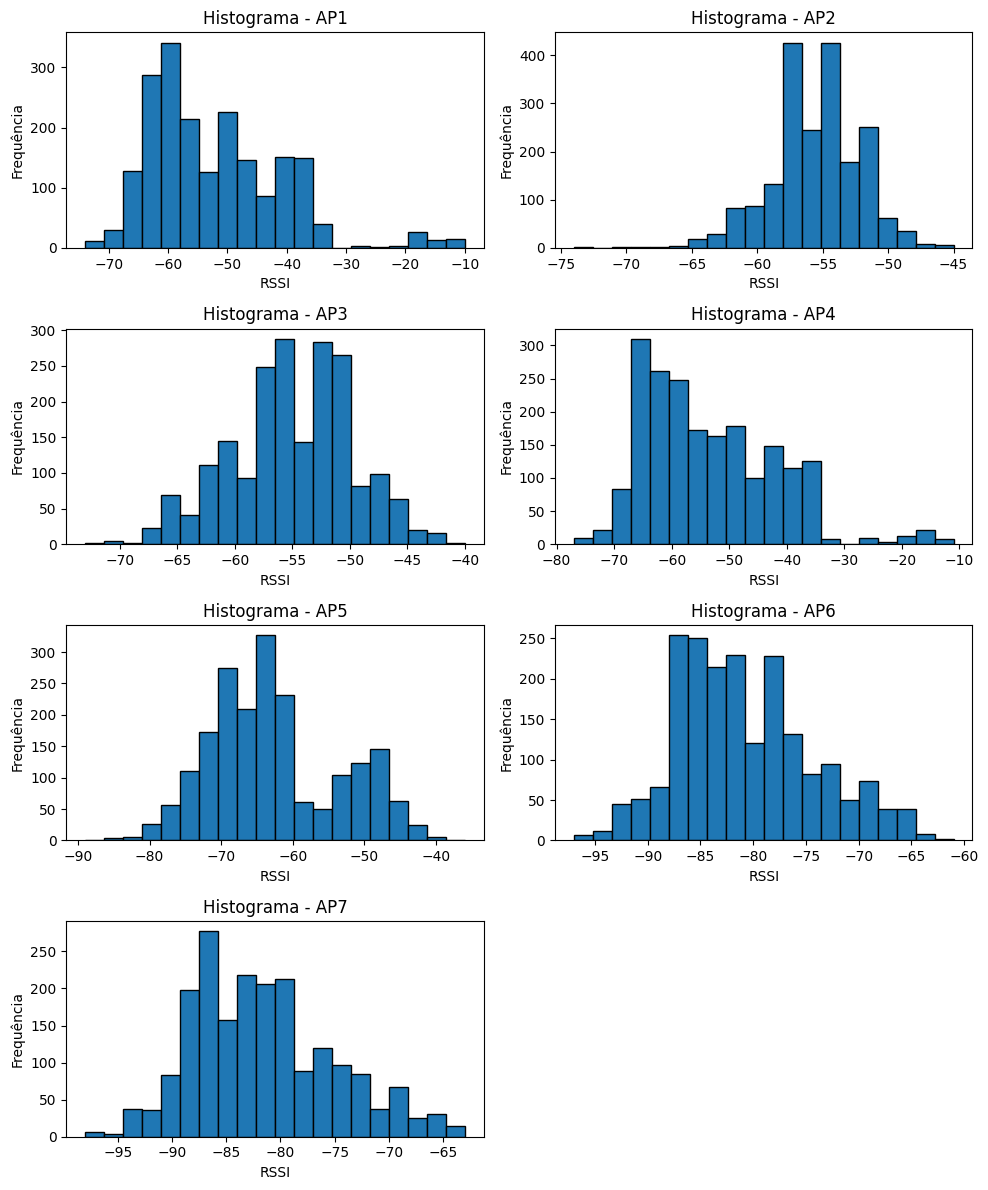

,mean,std,min,max,iqr
AP2,-55.62,3.42,-74.0,-45.0,5.0
AP3,-54.96,5.32,-73.0,-40.0,7.0
AP6,-80.98,6.52,-97.0,-61.0,9.0
AP7,-81.73,6.52,-98.0,-63.0,9.0
AP5,-62.64,9.11,-89.0,-36.0,13.0
AP1,-52.33,11.32,-74.0,-10.0,15.0
AP4,-53.57,11.47,-77.0,-11.0,17.0


Distribuições mais concentradas:
      std  iqr
AP2  3.42  5.0
AP3  5.32  7.0
AP6  6.52  9.0

Distribuições mais dispersas:
       std   iqr
AP5   9.11  13.0
AP1  11.32  15.0
AP4  11.47  17.0


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
axes = axes.flatten()

for i, col in enumerate(rssi_cols):
    axes[i].hist(df[col], bins=20, edgecolor="black")
    axes[i].set_title(f"Histograma - {col}")
    axes[i].set_xlabel("RSSI")
    axes[i].set_ylabel("Frequência")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

resumo_dispersao = df[rssi_cols].agg(["mean", "std", "min", "max"]).T
resumo_dispersao["iqr"] = df[rssi_cols].quantile(0.75) - df[rssi_cols].quantile(0.25)

resumo_dispersao = resumo_dispersao.sort_values(by="std")

display(resumo_dispersao.round(2))

print("Distribuições mais concentradas:")
print(resumo_dispersao.head(3)[["std", "iqr"]].round(2))

print("\nDistribuições mais dispersas:")
print(resumo_dispersao.tail(3)[["std", "iqr"]].round(2))

Os histogramas mostram que AP2 e AP3 possuem distribuições mais concentradas, com valores de RSSI próximos da média. AP6 e AP7 também apresentam concentração moderada, porém em faixas de sinal mais fracas. Já AP1, AP4 e AP5 apresentam maior dispersão, com valores espalhados em uma faixa maior de RSSI. Essa diferença pode influenciar a classificação e a clusterização, pois atributos mais dispersos podem ajudar a separar melhor as salas, enquanto atributos muito concentrados podem ter menor poder de diferenciação entre os ambientes.

### <font color='#2D9CDB'>Q5) Analise a distribuição das amostras entre as diferentes salas do dataset. Para isso, apresente a quantidade de exemplos pertencentes a cada classe e construa um gráfico de barras mostrando essa distribuição. Em seguida, informe se o conjunto de dados é balanceado e discuta brevemente como o balanceamento das classes pode influenciar o treinamento e a avaliação de modelos de classificação.</font>

,Quantidade,Percentual (%)
Room,,
1,500,25.0
2,500,25.0
3,500,25.0
4,500,25.0


Distribuição das classes:
      Quantidade  Percentual (%)
Room                            
1            500            25.0
2            500            25.0
3            500            25.0
4            500            25.0


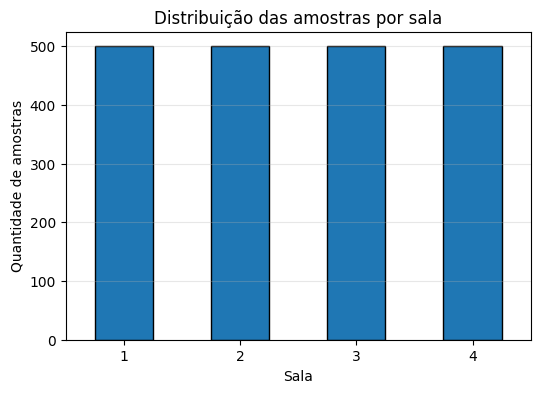

Menor classe: 500 amostras
Maior classe: 500 amostras
Diferença: 0 amostras


In [7]:
class_counts = df["Room"].value_counts().sort_index()
class_percent = df["Room"].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Quantidade": class_counts,
    "Percentual (%)": class_percent.round(2)
})

display(class_distribution)

print("Distribuição das classes:")
print(class_distribution)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribuição das amostras por sala")
plt.xlabel("Sala")
plt.ylabel("Quantidade de amostras")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

print(f"Menor classe: {class_counts.min()} amostras")
print(f"Maior classe: {class_counts.max()} amostras")
print(f"Diferença: {class_counts.max() - class_counts.min()} amostras")

A distribuição das amostras é totalmente balanceada. Cada uma das quatro classes possui 500 amostras, representando 25% do dataset. Esse balanceamento é positivo para modelos de classificação, pois evita que o treinamento favoreça uma sala específica.

### <font color='#2D9CDB'>Q6) Divida o dataset em conjuntos de treinamento e teste utilizando 70% das amostras para treinamento e 30% para teste. Utilize estratificação para preservar a proporção das classes em ambos os conjuntos. Em seguida, informe a quantidade de amostras presente em cada conjunto e verifique se a distribuição das classes foi mantida após a divisão.</font>

In [8]:
from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Amostras de treinamento: {X_train.shape[0]}")
print(f"Amostras de teste: {X_test.shape[0]}")

dist_train = pd.Series(y_train).value_counts().sort_index()
dist_test = pd.Series(y_test).value_counts().sort_index()

distribuicao = pd.DataFrame({
    "Treino": dist_train,
    "Teste": dist_test,
    "Treino (%)": (dist_train / len(y_train) * 100).round(2),
    "Teste (%)": (dist_test / len(y_test) * 100).round(2)
})

display(distribuicao)

Amostras de treinamento: 1400
Amostras de teste: 600


,Treino,Teste,Treino (%),Teste (%)
1,350,150,25.0,25.0
2,350,150,25.0,25.0
3,350,150,25.0,25.0
4,350,150,25.0,25.0


O dataset foi dividido em 1400 amostras para treinamento e 600 para teste. A estratificação manteve a distribuição original das classes. Portanto, a divisão preservou o balanceamento das classes.

# <font color='green'><u><b>Parte 2 - Árvore de Decisão</b></u></font>

<div class="alert alert-info">

As árvores de decisão são algoritmos de aprendizado supervisionado utilizados para tarefas de classificação e regressão. Diferentemente da regressão logística, que utiliza uma equação matemática para modelar a relação entre os atributos e a variável alvo, as árvores de decisão realizam previsões por meio de uma sequência de regras do tipo <i>"se-então"</i>. Durante o treinamento, o algoritmo seleciona os atributos que melhor separam as classes e constrói uma estrutura hierárquica composta por nós e ramificações. Uma das principais vantagens desse método é sua interpretabilidade, pois as decisões tomadas pelo modelo podem ser facilmente visualizadas e compreendidas. Nesta atividade, utilizaremos a implementação <code>DecisionTreeClassifier</code> da biblioteca Scikit-Learn. A documentação oficial pode ser consultada em: <a href="https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html" target="_blank">https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html</a>.

</div>

### <font color='#2D9CDB'>Q7) Treine uma árvore de decisão para classificar as salas do dataset utilizando os dados de treinamento. Em seguida, informe a profundidade da árvore, o número de nós folha e apresente uma visualização da estrutura aprendida pelo modelo. Com base na árvore obtida, identifique qual atributo foi utilizado no nó raiz e discuta brevemente o que isso indica sobre sua importância para o processo de classificação.</font>

Profundidade da árvore: 13
Número de nós folha: 37
Atributo do nó raiz: AP1
Limiar do nó raiz: -54.50


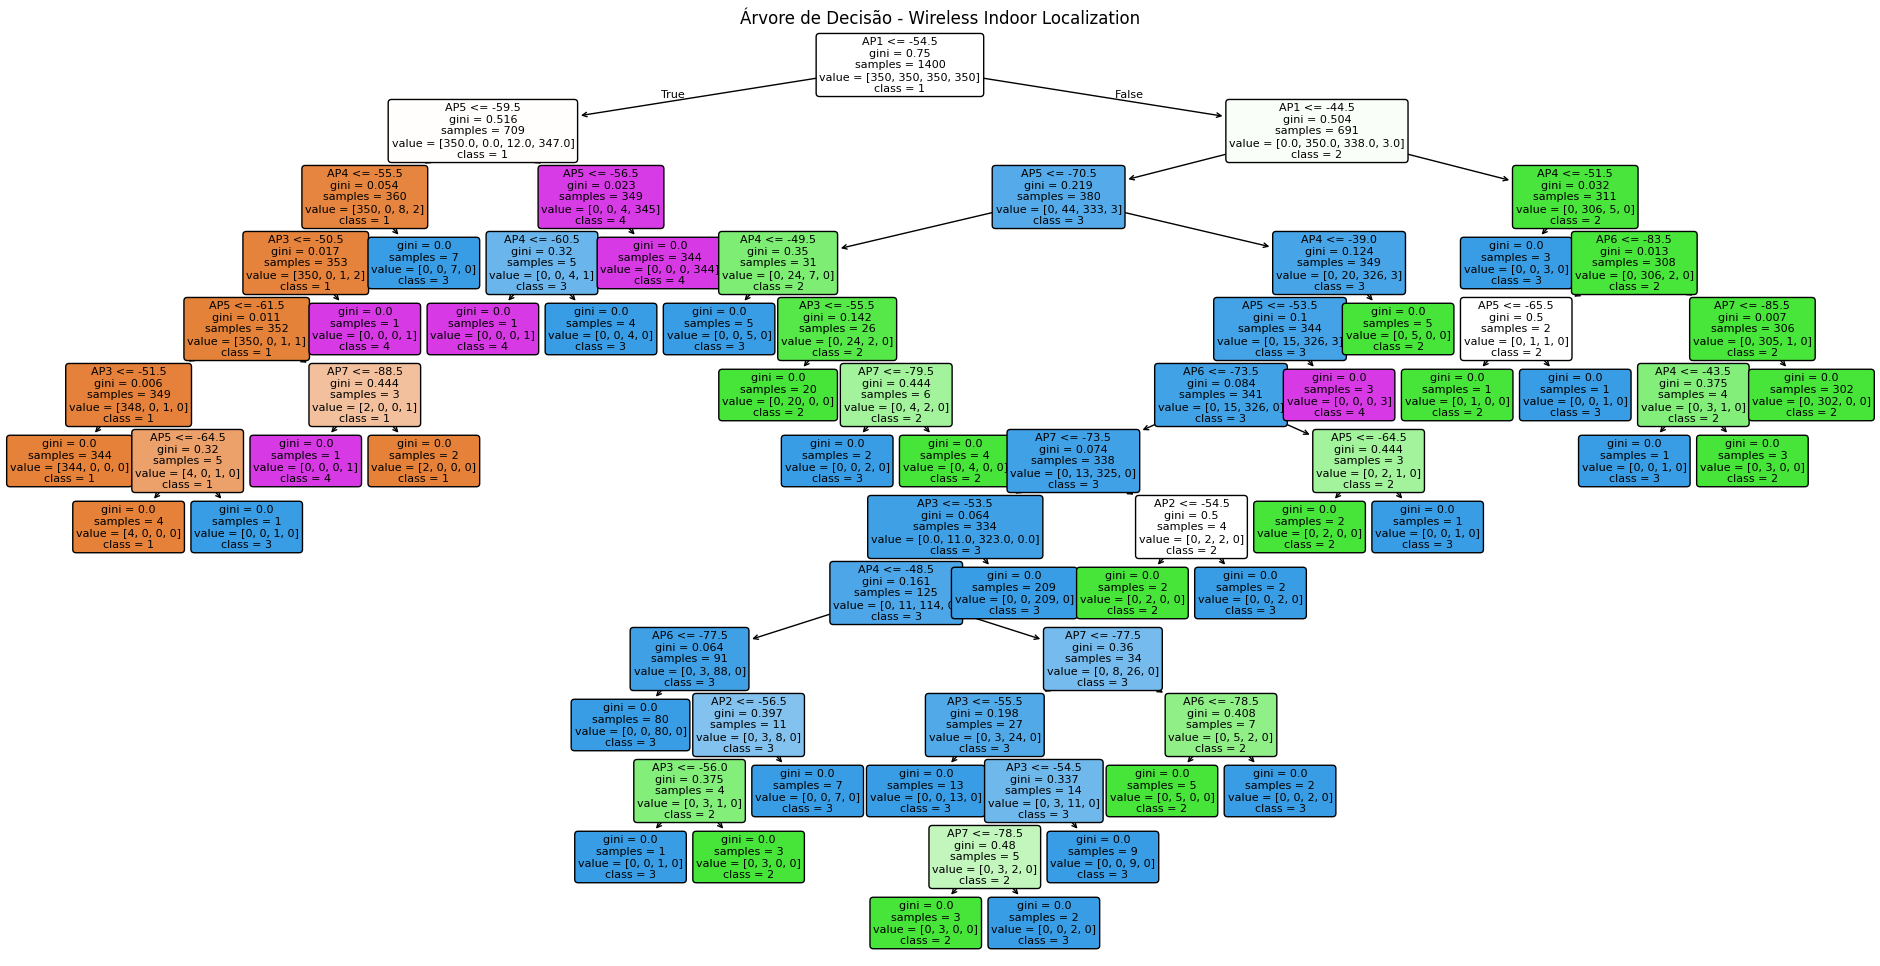

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

profundidade = dt_model.get_depth()
nos_folha = dt_model.get_n_leaves()

print(f"Profundidade da árvore: {profundidade}")
print(f"Número de nós folha: {nos_folha}")

root_feature_index = dt_model.tree_.feature[0]
root_feature_name = feature_names[root_feature_index]
root_threshold = dt_model.tree_.threshold[0]

print(f"Atributo do nó raiz: {root_feature_name}")
print(f"Limiar do nó raiz: {root_threshold:.2f}")

# IA
plt.figure(figsize=(24, 12))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=[str(c) for c in sorted(set(y))],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árvore de Decisão - Wireless Indoor Localization")
plt.show()

A árvore de decisão treinada apresentou profundidade 13 e 37 nós folha. O atributo utilizado no nó raiz foi AP1, com limiar de -54,50. Isso indica que o sinal recebido do ponto de acesso AP1 foi o primeiro critério escolhido pelo modelo para separar as salas, sendo considerado o atributo mais relevante no início do processo de classificação.

### <font color='#2D9CDB'>Q8) Utilize a árvore de decisão treinada para realizar predições sobre o conjunto de teste. Em seguida, calcule a acurácia do modelo e apresente a matriz de confusão correspondente. Com base nos resultados obtidos, analise o desempenho do classificador e identifique quais salas foram classificadas com maior e menor precisão.</font>

Acurácia do modelo: 0.9733


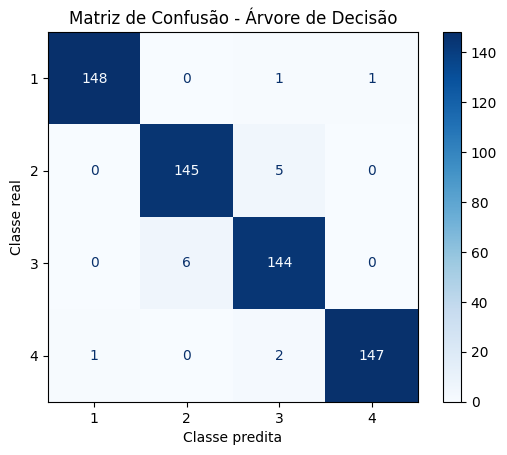

,Sala,Precisão
0,1,0.993289
1,2,0.960265
2,3,0.947368
3,4,0.993243


In [10]:
from sklearn.metrics import classification_report, precision_score

y_pred = dt_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acc:.4f}")

labels = sorted(set(y))

cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"Real {c}" for c in labels],
    columns=[f"Predito {c}" for c in labels]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.show()

precision_per_class = precision_score(
    y_test,
    y_pred,
    labels=labels,
    average=None
)

precision_df = pd.DataFrame({
    "Sala": labels,
    "Precisão": precision_per_class
})

display(precision_df)

melhor_sala = precision_df.loc[precision_df["Precisão"].idxmax()]
pior_sala = precision_df.loc[precision_df["Precisão"].idxmin()]

A árvore de decisão obteve acurácia de 0,9733 no conjunto de teste. Pela matriz de confusão, a maioria das amostras foi classificada corretamente, com poucos erros entre as salas 2 e 3. As salas com maior precisão foram 1 e 4, ambas com aproximadamente 0,99. A sala com menor precisão foi a sala 3.

### <font color='#2D9CDB'>Q9) Treine novas árvores de decisão limitando a profundidade máxima (`max_depth`) aos valores de 1 a 15. Para cada modelo, calcule a acurácia nos conjuntos de treinamento e teste. Em seguida, organize os resultados em uma tabela e construa um gráfico comparando as acurácias obtidas. Com base nos resultados, analise como a profundidade influencia a complexidade e o desempenho do modelo. Por fim, identifique se há evidências de sobreajuste e indique qual profundidade parece oferecer o melhor equilíbrio entre capacidade de aprendizado e generalização.</font>

In [11]:
resultados = []

for depth in range(1, 16):
    modelo = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    resultados.append({
        "max_depth": depth,
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test
    })

resultados_df = pd.DataFrame(resultados)

display(resultados_df.round(4))

melhor = resultados_df.loc[resultados_df["Acurácia Teste"].idxmax()]

print(f"Melhor profundidade: {int(melhor['max_depth'])}")
print(f"Melhor acurácia de teste: {melhor['Acurácia Teste']:.4f}")

,max_depth,Acurácia Treino,Acurácia Teste
0,1,0.5000,0.5000
1,2,0.9529,0.9633
2,3,0.9743,0.9700
3,4,0.9829,0.9733
4,5,0.9857,0.9767
5,6,0.9893,0.9733
6,7,0.9907,0.9783
7,8,0.9921,0.9767
8,9,0.9921,0.9800
9,10,0.9943,0.9750


Melhor profundidade: 9
Melhor acurácia de teste: 0.9800


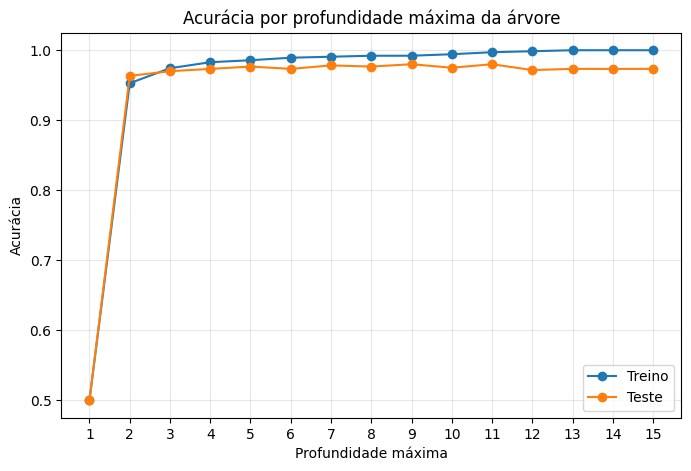

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    resultados_df["max_depth"],
    resultados_df["Acurácia Treino"],
    marker="o",
    label="Treino"
)

plt.plot(
    resultados_df["max_depth"],
    resultados_df["Acurácia Teste"],
    marker="o",
    label="Teste"
)

plt.title("Acurácia por profundidade máxima da árvore")
plt.xlabel("Profundidade máxima")
plt.ylabel("Acurácia")
plt.xticks(range(1, 16))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

A profundidade influencia diretamente a complexidade da árvore. Com profundidade 1, o modelo apresentou baixo desempenho, indicando subajuste. A partir da profundidade 2, a acurácia aumentou bastante, e os melhores resultados de teste ocorreram nas profundidades 9 e 11, com acurácia de 0,9800. Porém, nas profundidades maiores, a acurácia de treino chegou a 1,0000 enquanto a de teste não aumentou, indicando evidência de sobreajuste. Assim, a profundidade 9 parece oferecer o melhor equilíbrio, pois atinge a maior acurácia de teste com menor complexidade que profundidades mais altas.

### <font color='#2D9CDB'>Q10) Utilizando a árvore de decisão treinada, obtenha a importância de cada atributo RSSI por meio da propriedade `feature_importances_`. Em seguida, construa um gráfico de barras ordenando os atributos do mais importante para o menos importante. Com base nos resultados, identifique quais pontos de acesso contribuíram mais para a classificação das salas e discuta por que alguns atributos podem ser mais relevantes do que outros para o problema de localização indoor.</font>

,Atributo,Importância
0,AP1,0.5628
4,AP5,0.3660
3,AP4,0.0387
6,AP7,0.0121
2,AP3,0.0086
5,AP6,0.0073
1,AP2,0.0046


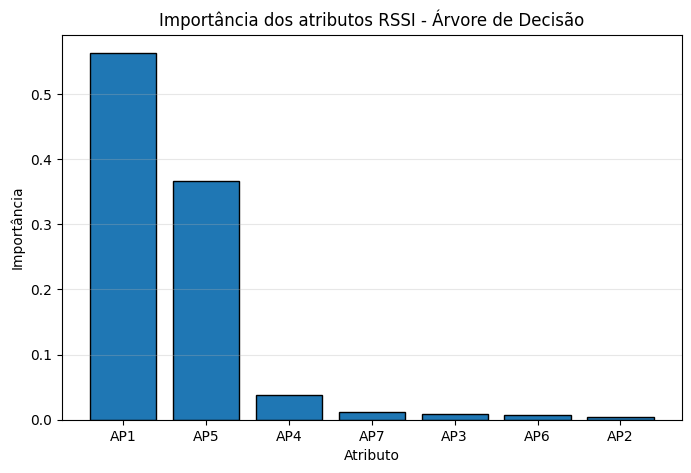

Atributo mais importante:
Atributo            AP1
Importância    0.562765
Name: 0, dtype: object

Atributo menos importante:
Atributo            AP2
Importância    0.004632
Name: 1, dtype: object


In [13]:
importancias = dt_model.feature_importances_

importancias_df = pd.DataFrame({
    "Atributo": feature_names,
    "Importância": importancias
}).sort_values(by="Importância", ascending=False)

display(importancias_df.round(4))

plt.figure(figsize=(8, 5))
plt.bar(importancias_df["Atributo"], importancias_df["Importância"], edgecolor="black")

plt.title("Importância dos atributos RSSI - Árvore de Decisão")
plt.xlabel("Atributo")
plt.ylabel("Importância")
plt.grid(axis="y", alpha=0.3)

plt.show()

print("Atributo mais importante:")
print(importancias_df.iloc[0])

print("\nAtributo menos importante:")
print(importancias_df.iloc[-1])

Os atributos mais importantes foram AP1 e AP5, com importâncias de 0,5628 e 0,3660, respectivamente. Isso indica que esses dois pontos de acesso foram os que mais contribuíram para separar as salas. Os demais atributos tiveram importância bem menor. Essa diferença ocorre porque alguns sinais RSSI variam mais entre as salas e fornecem mais informação para distinguir os ambientes, enquanto outros apresentam padrões mais parecidos e contribuem menos para a classificação.

# <font color='green'><u><b>Parte 3 - K-Means</b></u></font>

### <font color='#2D9CDB'>Q11) Diferentemente das árvores de decisão, o algoritmo k-Means não utiliza rótulos durante o treinamento. Pesquise brevemente sobre esse método e descreva, em um único parágrafo, o que é clusterização, qual é o objetivo do algoritmo k-Means, o significado de um centroide e como o algoritmo utiliza a distância entre as amostras para formar agrupamentos.</font>

Clusterização é uma técnica de aprendizado não supervisionado que agrupa amostras semelhantes entre si, sem usar rótulos conhecidos. O objetivo do k-Means é dividir os dados em k grupos, buscando formar clusters compactos e bem separados. Cada cluster é representado por um centroide, que corresponde ao ponto médio das amostras atribuídas a esse grupo. O algoritmo funciona calculando a distância entre cada amostra e os centroides, associando cada amostra ao centroide mais próximo; depois, os centroides são recalculados e o processo se repete até que os grupos fiquem estáveis.

### <font color='#2D9CDB'>Q12) Considere os dois atributos mais importantes identificados na Q10. Construa um gráfico de dispersão utilizando essas variáveis, representando as amostras de cada sala com cores distintas e uma legenda apropriada. Com base na visualização obtida, analise a distribuição das amostras e discuta se existem agrupamentos naturais nos dados. Na sua opinião, seria possível identificar as diferentes salas sem utilizar os rótulos originais?</font>

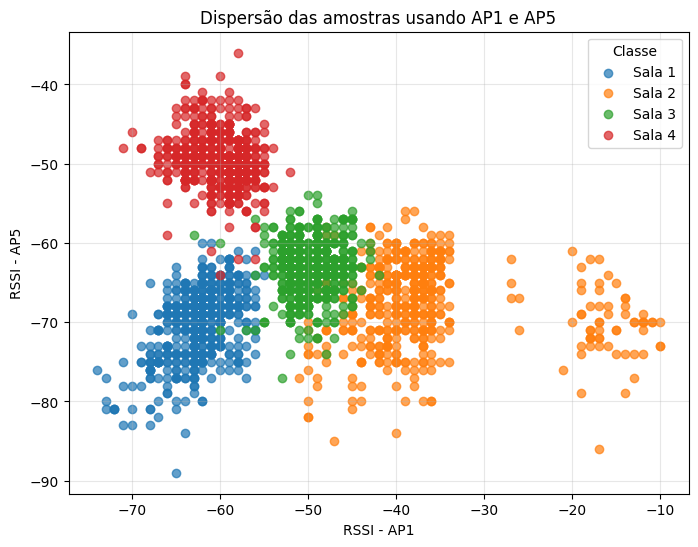

In [14]:
attr_x = "AP1"
attr_y = "AP5"

plt.figure(figsize=(8, 6))

for sala in sorted(df["Room"].unique()):
    dados_sala = df[df["Room"] == sala]

    plt.scatter(
        dados_sala[attr_x],
        dados_sala[attr_y],
        label=f"Sala {sala}",
        alpha=0.7
    )

plt.title("Dispersão das amostras usando AP1 e AP5")
plt.xlabel("RSSI - AP1")
plt.ylabel("RSSI - AP5")
plt.legend(title="Classe")
plt.grid(True, alpha=0.3)

plt.show()

A dispersão mostra agrupamentos visuais bem definidos para algumas salas. Porém, existe sobreposição entre algumas classes, principalmente entre as salas 2 e 3. Assim, seria possível identificar agrupamentos naturais sem usar os rótulos originais, mas a separação não seria perfeita.

### <font color='#2D9CDB'>Q13) Antes de aplicar o algoritmo k-Means, é necessário definir o número de clusters (*k*). Utilize o Método do Cotovelo (Elbow Method) para avaliar valores de *k* entre 1 e 10. Para cada valor, calcule a inércia do modelo e construa um gráfico relacionando o número de clusters e a inércia obtida. Com base no gráfico, identifique o valor de *k* que parece mais adequado para este conjunto de dados e justifique sua escolha.</font>

In [15]:
from sklearn.preprocessing import StandardScaler

X_kmeans = df[feature_names].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kmeans)

k_values = range(1, 11)
inercias = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "Inércia": inercias
})

display(elbow_df.round(2))

,k,Inércia
0,1,14000.00
1,2,9070.65
2,3,6860.92
3,4,5508.19
4,5,5030.43
5,6,4618.57
6,7,4286.15
7,8,3970.03
8,9,3779.06
9,10,3628.55


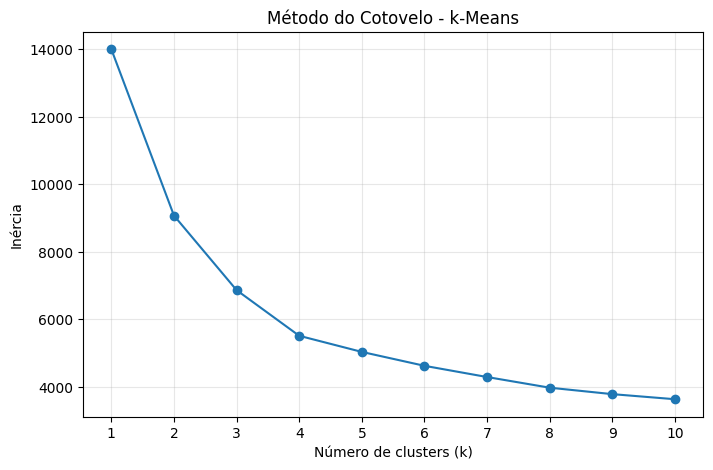

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    elbow_df["k"],
    elbow_df["Inércia"],
    marker="o"
)

plt.title("Método do Cotovelo - k-Means")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.show()

Pelo Método do Cotovelo, a inércia diminui rapidamente entre k = 1 e k = 4, indicando grande melhora na formação dos agrupamentos. Após k = 4, a redução passa a ser menor e mais gradual. Assim, o valor mais adequado parece ser k = 4, pois representa o ponto em que o ganho adicional começa a diminuir.

### <font color='#2D9CDB'>Q14) Utilizando o valor de *k* identificado na Q13, treine um modelo k-Means empregando apenas os atributos AP1 e AP5. Em seguida, apresente as coordenadas dos centroides encontrados e construa um gráfico de dispersão mostrando as amostras coloridas de acordo com o cluster atribuído pelo algoritmo. Destaque também os centroides no gráfico. Com base nos resultados, analise a qualidade dos agrupamentos obtidos.</font>

In [17]:
k_ideal = 4

atributos_kmeans = ["AP1", "AP5"]
X_ap1_ap5 = df[atributos_kmeans].values

scaler = StandardScaler()
X_ap1_ap5_scaled = scaler.fit_transform(X_ap1_ap5)

kmeans_ap1_ap5 = KMeans(
    n_clusters=k_ideal,
    random_state=42,
    n_init=10
)

clusters = kmeans_ap1_ap5.fit_predict(X_ap1_ap5_scaled)

centroides = scaler.inverse_transform(kmeans_ap1_ap5.cluster_centers_)

centroides_df = pd.DataFrame(
    centroides,
    columns=atributos_kmeans
)

centroides_df.index = [f"Cluster {i}" for i in range(k_ideal)]

display(centroides_df.round(2))

,AP1,AP5
Cluster 0,-34.87,-68.05
Cluster 1,-60.21,-49.37
Cluster 2,-62.32,-70.80
Cluster 3,-49.15,-63.32


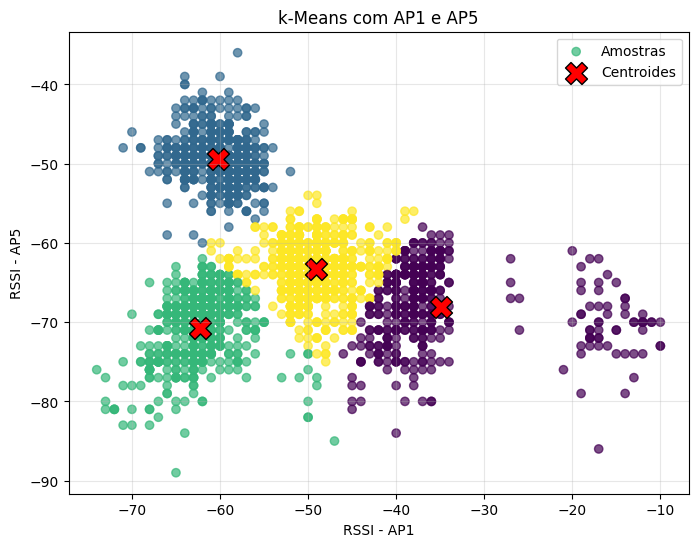

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["AP1"],
    df["AP5"],
    c=clusters,
    cmap="viridis",
    alpha=0.7,
    label="Amostras"
)

plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolor="black",
    label="Centroides"
)

plt.title("k-Means com AP1 e AP5")
plt.xlabel("RSSI - AP1")
plt.ylabel("RSSI - AP5")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Com k = 4 e usando apenas AP1 e AP5, o k-Means formou quatro agrupamentos principais. A qualidade dos agrupamentos é boa visualmente, pois os clusters apresentam regiões bem definidas. Porém, há alguma sobreposição entre grupos próximos, principalmente na região central, indicando que apenas AP1 e AP5 ajudam bastante na separação, mas não representam perfeitamente todas as salas.

### <font color='#2D9CDB'>Q15) Compare os clusters encontrados pelo k-Means com as salas reais do dataset. Para isso, construa uma <a href="https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html">tabela de contingência</a> relacionando cada sala aos clusters atribuídos pelo algoritmo. Em seguida, identifique qual cluster representa predominantemente cada sala e calcule a porcentagem de amostras associadas a esse agrupamento. Com base nos resultados, discuta quais salas foram mais facilmente identificadas pelo algoritmo e quais apresentaram maior grau de confusão com outros grupos.</font>

In [19]:
df_clusters = df.copy()
df_clusters["Cluster"] = clusters

contingencia = pd.crosstab(
    df_clusters["Room"],
    df_clusters["Cluster"]
)

display(contingencia)

contingencia_percentual = contingencia.div(
    contingencia.sum(axis=1),
    axis=0
) * 100

display(contingencia_percentual.round(2))

resumo_clusters = pd.DataFrame({
    "Cluster predominante": contingencia.idxmax(axis=1),
    "Quantidade": contingencia.max(axis=1),
    "Percentual (%)": contingencia_percentual.max(axis=1).round(2)
})

display(resumo_clusters)

Cluster,0,1,2,3
Room,,,,
1,0,1,476,23
2,396,0,10,94
3,0,2,8,490
4,0,494,1,5


Cluster,0,1,2,3
Room,,,,
1,0.0,0.2,95.2,4.6
2,79.2,0.0,2.0,18.8
3,0.0,0.4,1.6,98.0
4,0.0,98.8,0.2,1.0


,Cluster predominante,Quantidade,Percentual (%)
Room,,,
1,2,476,95.2
2,0,396,79.2
3,3,490,98.0
4,1,494,98.8


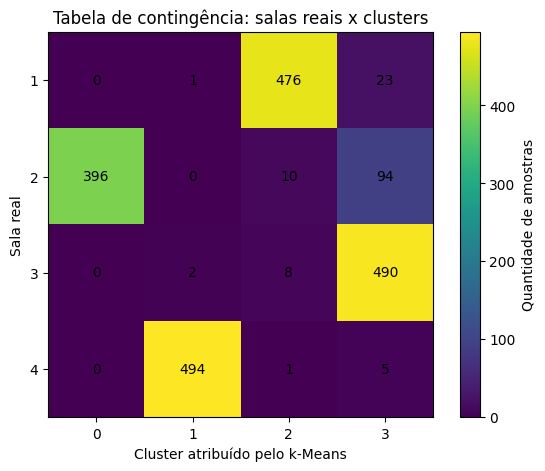

In [20]:
plt.figure(figsize=(7, 5))

plt.imshow(contingencia.values)

plt.title("Tabela de contingência: salas reais x clusters")
plt.xlabel("Cluster atribuído pelo k-Means")
plt.ylabel("Sala real")

plt.xticks(
    ticks=range(len(contingencia.columns)),
    labels=contingencia.columns
)

plt.yticks(
    ticks=range(len(contingencia.index)),
    labels=contingencia.index
)

for i in range(contingencia.shape[0]):
    for j in range(contingencia.shape[1]):
        plt.text(
            j,
            i,
            contingencia.iloc[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Quantidade de amostras")
plt.show()

A comparação mostra que o k-Means conseguiu identificar bem a maioria dos grupos. A sala 1 foi representada principalmente pelo cluster 2, com 476 amostras, equivalente a 95,2%. A sala 2 foi representada pelo cluster 0, com 396 amostras, equivalente a 79,2%, mas apresentou maior confusão com o cluster 3. A sala 3 foi representada pelo cluster 3, com 490 amostras, equivalente a 98,0%. A sala 4 foi representada pelo cluster 1, com 494 amostras, equivalente a 98,8%. Assim, as salas 3 e 4 foram as mais facilmente identificadas, enquanto a sala 2 apresentou maior grau de confusão.

# <font color='green'><u><b>Parte 4 - Detecção de Anomalias</b></u></font>

### <font color='#2D9CDB'>Q16) Uma aplicação comum de algoritmos de clusterização é a detecção de anomalias. Em geral, amostras localizadas muito longe do centroide de seu cluster podem representar comportamentos incomuns ou situações atípicas. Utilizando os dois atributos mais importantes identificados na Q10, calcule a distância euclidiana de cada amostra ao centroide do cluster ao qual ela foi atribuída pelo k-Means. Em seguida, apresente um histograma dessas distâncias e informe os valores mínimo, máximo, médio e o desvio padrão observados. Com base nos resultados, discuta o que essas distâncias revelam sobre a compactação dos clusters encontrados.</font>

Distância mínima: 0.0125
Distância máxima: 2.5262
Distância média: 0.5214
Desvio padrão: 0.3484


,Distancia_Centroide
count,2000.0000
mean,0.5214
std,0.3485
min,0.0125
25%,0.2970
50%,0.4451
75%,0.6525
max,2.5262


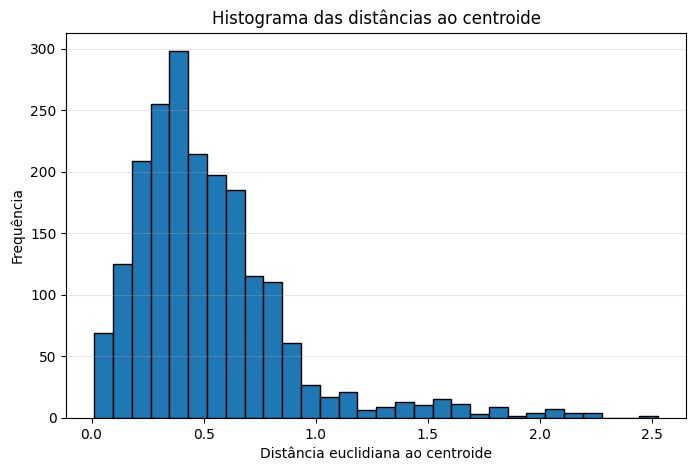

In [21]:
distancias = np.linalg.norm(
    X_ap1_ap5_scaled - kmeans_ap1_ap5.cluster_centers_[clusters],
    axis=1
)

df_anomalias = df.copy()
df_anomalias["Cluster"] = clusters
df_anomalias["Distancia_Centroide"] = distancias

estatisticas_distancias = df_anomalias["Distancia_Centroide"].describe()

print(f"Distância mínima: {distancias.min():.4f}")
print(f"Distância máxima: {distancias.max():.4f}")
print(f"Distância média: {distancias.mean():.4f}")
print(f"Desvio padrão: {distancias.std():.4f}")

display(estatisticas_distancias.round(4))

plt.figure(figsize=(8, 5))

plt.hist(
    df_anomalias["Distancia_Centroide"],
    bins=30,
    edgecolor="black"
)

plt.title("Histograma das distâncias ao centroide")
plt.xlabel("Distância euclidiana ao centroide")
plt.ylabel("Frequência")
plt.grid(axis="y", alpha=0.3)

plt.show()

As distâncias ao centroide variaram de 0,0125 a 2,5262, com média de 0,5214 e desvio padrão de 0,3484. A maior parte das amostras ficou concentrada em distâncias baixas, principalmente abaixo de 1,0, indicando que os clusters formados são relativamente compactos. Porém, existem algumas amostras mais distantes dos centroides, visíveis na cauda do histograma, que podem representar pontos menos típicos ou possíveis anomalias dentro dos agrupamentos.

### <font color='#2D9CDB'>Q17) Considere que amostras muito distantes do centroide de seu cluster podem ser classificadas como potenciais anomalias. Utilize o percentil de 95% das distâncias calculadas na Q16 como limiar de detecção. Em seguida, identifique todas as amostras cuja distância ao centroide seja superior a esse valor, informe quantas anomalias foram encontradas e apresente as cinco amostras mais distantes de seus respectivos centroides. Com base nos resultados, discuta se o critério adotado parece adequado para identificar observações atípicas.</font>

In [22]:
limiar_95 = np.percentile(df_anomalias["Distancia_Centroide"], 95)

anomalias = df_anomalias[
    df_anomalias["Distancia_Centroide"] > limiar_95
].copy()

top5_anomalias = anomalias.sort_values(
    by="Distancia_Centroide",
    ascending=False
).head(5)

print(f"Limiar percentil 95%: {limiar_95:.4f}")
print(f"Quantidade de anomalias encontradas: {len(anomalias)}")

display(top5_anomalias[
    ["AP1", "AP5", "Room", "Cluster", "Distancia_Centroide"]
])

Limiar percentil 95%: 1.1782
Quantidade de anomalias encontradas: 100


,AP1,AP5,Room,Cluster,Distancia_Centroide
609,-17,-86,2,0,2.526230
769,-10,-73,2,0,2.263818
873,-10,-73,2,0,2.263818
870,-10,-70,2,0,2.207962
604,-14,-79,2,0,2.201775


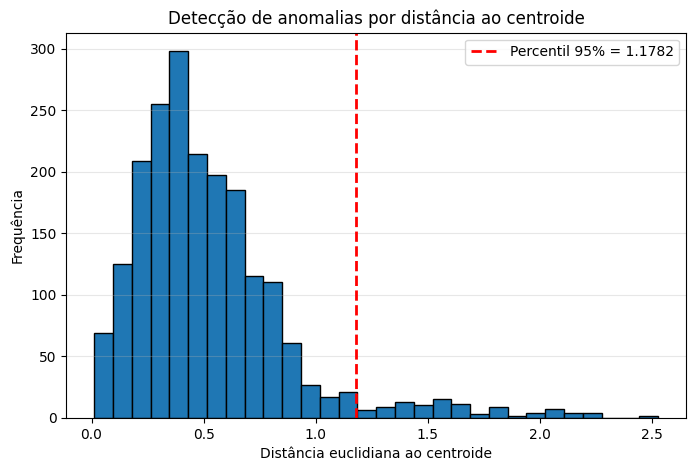

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_anomalias["Distancia_Centroide"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    limiar_95,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Percentil 95% = {limiar_95:.4f}"
)

plt.title("Detecção de anomalias por distância ao centroide")
plt.xlabel("Distância euclidiana ao centroide")
plt.ylabel("Frequência")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

O limiar definido foi 1,1782, resultando em 100 amostras classificadas como potenciais anomalias. As cinco amostras mais distantes pertencem à sala 2 e ao cluster 0, com distâncias entre 2,2018 e 2,5262, indicando que estão bem afastadas do centroide do grupo. O critério parece adequado para destacar observações atípicas, pois seleciona apenas os 5% mais distantes. Porém, como o limiar é estatístico, essas amostras não são necessariamente erros, elas podem representar variações reais do sinal RSSI dentro da sala.

### <font color='#2D9CDB'>Q18) Construa um gráfico de dispersão utilizando os dois atributos empregados pelo k-Means e destaque as anomalias identificadas na Q17. Represente também os centroides dos clusters. Com base na visualização obtida, avalie se as amostras classificadas como anômalas encontram-se em regiões afastadas dos centroides e discuta se os resultados são coerentes com o critério de detecção adotado.</font>

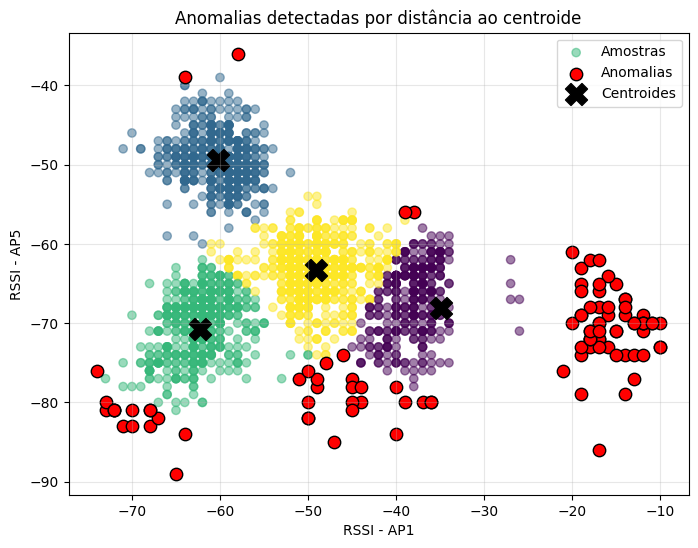

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_anomalias["AP1"],
    df_anomalias["AP5"],
    c=df_anomalias["Cluster"],
    cmap="viridis",
    alpha=0.5,
    label="Amostras"
)

plt.scatter(
    anomalias["AP1"],
    anomalias["AP5"],
    c="red",
    marker="o",
    edgecolor="black",
    s=80,
    label="Anomalias"
)

plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    c="black",
    marker="X",
    s=250,
    label="Centroides"
)

plt.title("Anomalias detectadas por distância ao centroide")
plt.xlabel("RSSI - AP1")
plt.ylabel("RSSI - AP5")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

A visualização mostra que as anomalias identificadas estão nas bordas dos agrupamentos ou em regiões afastadas dos centroides. Isso é mais evidente nos pontos à direita do gráfico e nos pontos com valores mais extremos de AP1 e AP5. Portanto, os resultados são coerentes com o critério adotado, pois o método selecionou amostras com maior distância em relação ao centroide do cluster. Ainda assim, essas amostras devem ser tratadas como potenciais anomalias, pois podem representar apenas variações naturais do sinal RSSI.

### <font color='#2D9CDB'>Q19) O limiar utilizado para detectar anomalias influencia diretamente a quantidade de observações classificadas como atípicas. Repita o procedimento da Q17 utilizando os percentis 90%, 95% e 99% das distâncias aos centroides. Para cada caso, registre o valor do limiar e o número de anomalias detectadas. Organize os resultados em uma tabela e discuta como a escolha do percentil afeta a sensibilidade do detector de anomalias.</font>

In [25]:
percentis = [90, 95, 99]
resultados_percentis = []

distancias = df_anomalias["Distancia_Centroide"]

for p in percentis:
    limiar = np.percentile(distancias, p)
    quantidade_anomalias = (distancias > limiar).sum()

    resultados_percentis.append({
        "Percentil": f"{p}%",
        "Limiar": limiar,
        "Quantidade de anomalias": quantidade_anomalias
    })

anomalias_percentis_df = pd.DataFrame(resultados_percentis)

display(anomalias_percentis_df.round(4))

,Percentil,Limiar,Quantidade de anomalias
0,90%,0.8825,200
1,95%,1.1782,100
2,99%,1.8742,20


A escolha do percentil altera diretamente a sensibilidade do detector. Com percentil 90%, o limiar foi menor, 0,8825, e 200 amostras foram classificadas como anomalias, tornando o método mais sensível. Com percentil 95%, foram detectadas 100 anomalias. Já com percentil 99%, o limiar aumentou para 1,8742 e apenas 20 amostras foram classificadas como anômalas. Portanto, percentis menores detectam mais possíveis anomalias, enquanto percentis maiores tornam o critério mais restritivo.


# <font color='green'><u><b>Parte 5 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q20) Ao longo desta atividade foram exploradas técnicas de aprendizado supervisionado (Árvores de Decisão) e não supervisionado (k-Means), além de uma abordagem simples para detecção de anomalias baseada na distância aos centroides. Compare essas três aplicações quanto aos seus objetivos, à utilização de rótulos durante o treinamento, aos resultados produzidos e às situações em que cada uma delas é mais adequada. Por fim, discuta como essas técnicas poderiam ser utilizadas em conjunto em um sistema de localização indoor baseado em sinais Wi-Fi.</font>

A árvore de decisão é uma técnica supervisionada, pois utiliza os rótulos das salas durante o treinamento para aprender regras de classificação. Seu objetivo é prever a sala correta a partir dos valores de RSSI, produzindo como resultado uma classe para cada amostra. Já o k-Means é uma técnica não supervisionada, pois não utiliza os rótulos originais, seu objetivo é agrupar amostras semelhantes com base na distância aos centroides, produzindo clusters. A detecção de anomalias baseada nos centroides também não depende diretamente dos rótulos e busca identificar amostras muito afastadas do comportamento típico de seu grupo. Em um sistema de localização indoor, essas técnicas poderiam ser usadas em conjunto: a árvore de decisão faria a classificação principal da sala, o k-Means ajudaria a identificar padrões naturais nos sinais Wi-Fi e a detecção de anomalias poderia sinalizar leituras incomuns, ruídos ou situações em que a previsão não é confiável.